# Fashionpedia · Mask R-CNN (v2) — Entrenamiento en Google Colab + refinado con SAM 2

Este notebook entrena un modelo **Mask R-CNN** (ResNet50-FPN v2) sobre **Fashionpedia** y después refina sus máscaras con **SAM 2** para obtener, por cada prenda, una máscara limpia lista para recolorear o cambiar de textura.

**Cambios respecto a la versión anterior:**
1. **Mayor resolución**: la imagen ya no se deforma a 256×256; se mantiene la relación de aspecto (lado largo ≤ `MAX_SIDE`) y la red trabaja a ~512×768.
2. **mAP (COCO)** de segmentación y de cajas, calculado en cada época, mAP por clase al final, y `best.pth` elegido por mAP (no por la pérdida).
3. **Augmentation**: flip horizontal, jitter de color y escala aleatoria (multi-scale training). Además: mixed precision (AMP), warm-up del learning rate y recorte de gradientes.
4. **Refinado con SAM 2** y lógica **prenda + partes − cierres** (sección 11).

> **Antes de ejecutar:** en Colab ve a `Entorno de ejecución → Cambiar tipo de entorno de ejecución` y selecciona **GPU** (T4 o superior).

## 1. Comprobar GPU e instalar dependencias

In [1]:
!nvidia-smi

Fri Oct  2 07:06:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# pycocotools no viene preinstalado en Colab
!pip install -q pycocotools

In [3]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA disponible: True
GPU: Tesla T4


## 2. Montar Google Drive

Se usa para leer el dataset (imágenes + anotaciones) y para guardar los checkpoints del modelo entrenado, de forma que no se pierdan si se reinicia el entorno de Colab.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuración de rutas

Ajusta estas rutas según dónde tengas subido el dataset de Fashionpedia dentro de tu Google Drive. Por defecto se asume una estructura como:

```
MyDrive/
└── fashionpedia/
    ├── train/                                  (imágenes de entrenamiento)
    ├── test_no_humans/                         (imágenes de validación)
    ├── instances_train_no_humans.json
    └── instances_test_no_humans.json
```

Los checkpoints se guardarán en `checkpoint_dir`, también dentro de Drive.

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving not_human_test.zip to not_human_test.zip


In [ ]:
import zipfile

with zipfile.ZipFile('not_human_test.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/fashionpedia')

In [5]:
DRIVE_ROOT = "/content/drive/MyDrive/fashionpedia"

TRAIN_IMAGES_DIR = f"{DRIVE_ROOT}/not_human"
TRAIN_ANNOTATIONS = f"{DRIVE_ROOT}/instances_no_humans.json"

TEST_IMAGES_DIR = f"{DRIVE_ROOT}/not_human_test"
TEST_ANNOTATIONS = f"{DRIVE_ROOT}/instances_test_no_humans.json"

VAL_FRACTION = 0.116
SPLIT_SEED = 42

# Carpeta para guardar los checkpoints
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints_768"

# ---- Resolución ----
# Las imágenes se reducen (sin deformar) para que su lado largo sea <= MAX_SIDE.
# Después, el propio modelo las reescala al tamaño de entrada:
#   - en train elige al azar uno de MIN_SIZE para el lado corto (augmentation de escala)
#   - en eval/inferencia usa el último valor (512)
# Con fotos 2:3 (p. ej. 512x768) la entrada final es justo 512x768.
MAX_SIDE = 768
MIN_SIZE = (384, 416, 448, 480, 512)

# ---- Hiperparámetros de entrenamiento ----
BATCH_SIZE = 2
EPOCHS = 10
LEARNING_RATE = 0.0025   # 0.005 antes
WARMUP_ITERS = 500       # el lr sube linealmente durante la 1ª época
LR_STEP_SIZE = 3         # el lr se divide entre 10 cada LR_STEP_SIZE épocas
WORKERS = 2
USE_AMP = True           # mixed precision: más rápido y menos memoria en la T4
AUGMENT = True           # flip horizontal + jitter de color
PRETRAINED = True

MAX_TRAIN_IMAGES = None
MAX_VAL_IMAGES = None
MAP_VAL_IMAGES = 300     # nº de imágenes de validación para calcular el mAP en cada época (None = todas)

## 4. Dataset (`FashionpediaDataset`)

Novedades:
- La imagen **conserva su relación de aspecto** (solo se reduce si su lado largo supera `max_side`).
- Las cajas se **recalculan a partir de las máscaras** ya transformadas (así nunca quedan desalineadas tras el reescalado o el flip) y se descartan las instancias que desaparecen.
- Con `train=True` se aplica **augmentation**: flip horizontal y jitter de color. La escala aleatoria la hace el modelo (`MIN_SIZE`).
- `with_mode(train=False)` devuelve una vista del mismo dataset sin augmentation (comparte las anotaciones, no duplica memoria).

In [6]:
import copy
import os
import random
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision.transforms import ColorJitter
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask


class FashionpediaDataset(Dataset):
    """
    __len__: cuántos elementos tiene el dataset en total
    __getitem__: obtiene el elemento número i (imagen + target con cajas, etiquetas y máscaras)
    """

    def __init__(self, images_dir, annotations_file, max_side=768, train=False,
                 hflip_prob=0.5, color_jitter=True):
        self.images_dir = images_dir
        self.max_side = max_side
        self.train = train
        self.hflip_prob = hflip_prob
        self.jitter = (
            ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.02)
            if color_jitter else None
        )

        self.coco = COCO(annotations_file)

        all_images_ids = list(sorted(self.coco.imgs.keys()))
        self.image_ids = [
            img_id for img_id in all_images_ids
            if os.path.isfile(os.path.join(self.images_dir, self.coco.imgs[img_id]["file_name"]))
        ]

        n_total = len(all_images_ids)
        n_encontradas = len(self.image_ids)
        if n_encontradas < n_total:
            print(
                f"Aviso: de {n_total} imágenes en el JSON, solo se encontraron "
                f"{n_encontradas} en '{self.images_dir}'. Se usarán solo esas."
            )

        category_ids = sorted(self.coco.getCatIds())
        self.categoryid_to_index = {category_id: i + 1 for i, category_id in enumerate(category_ids)}
        self.index_to_categoryid = {v: k for k, v in self.categoryid_to_index.items()}
        self.catid_to_name = {c["id"]: c["name"] for c in self.coco.loadCats(category_ids)}

    def with_mode(self, train):
        """Misma data (comparte COCO y lista de imágenes) pero con/sin augmentation."""
        other = copy.copy(self)
        other.train = train
        return other

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.imgs[image_id]
        width, height = info["width"], info["height"]

        image = Image.open(os.path.join(self.images_dir, info["file_name"])).convert("RGB")
        masks, labels = self._decode_instances(image_id, height, width)

        # 1) Reescalado manteniendo la relación de aspecto (solo si se pasa de max_side)
        scale = min(1.0, self.max_side / max(width, height))
        new_w, new_h = max(1, round(width * scale)), max(1, round(height * scale))
        if (image.width, image.height) != (new_w, new_h):
            image = image.resize((new_w, new_h), Image.Resampling.BILINEAR)
        if scale < 1.0:
            # bilinear + umbral: conserva mejor los objetos finos (cremalleras, solapas) que NEAREST
            masks = [
                (np.array(Image.fromarray(m * 255).resize((new_w, new_h), Image.Resampling.BILINEAR)) > 127)
                .astype(np.uint8)
                for m in masks
            ]

        # 2) Augmentation (solo en entrenamiento)
        if self.train:
            if random.random() < self.hflip_prob:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
                masks = [np.ascontiguousarray(m[:, ::-1]) for m in masks]
            if self.jitter is not None:
                image = self.jitter(image)

        # 3) Cajas recalculadas a partir de las máscaras finales (se descartan las vacías)
        boxes, kept_masks, kept_labels = [], [], []
        for m, label in zip(masks, labels):
            rows, columns = np.where(m)
            if rows.size == 0:
                continue
            boxes.append([columns.min(), rows.min(), columns.max() + 1, rows.max() + 1])
            kept_masks.append(m)
            kept_labels.append(label)

        image_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0
        n = len(kept_masks)
        if n:
            masks_t = torch.from_numpy(np.stack(kept_masks)).to(torch.uint8)
        else:
            masks_t = torch.zeros((0, new_h, new_w), dtype=torch.uint8)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.tensor(kept_labels, dtype=torch.int64),
            "masks": masks_t,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": masks_t.flatten(1).sum(dim=1).to(torch.float32),
            "iscrowd": torch.zeros((n,), dtype=torch.int64),
        }
        return image_tensor, target

    def _decode_instances(self, image_id, height, width):
        annotations = self.coco.loadAnns(self.coco.getAnnIds(imgIds=image_id))
        masks, labels = [], []
        for annotation in annotations:
            segmentation = annotation["segmentation"]
            if isinstance(segmentation, list):
                rle = coco_mask.merge(coco_mask.frPyObjects(segmentation, height, width))
            elif isinstance(segmentation["counts"], list):
                rle = coco_mask.frPyObjects(segmentation, height, width)
            else:
                rle = segmentation

            instance_mask = coco_mask.decode(rle)
            if instance_mask.ndim == 3:
                instance_mask = np.any(instance_mask, axis=2)
            instance_mask = instance_mask.astype(np.uint8)
            if instance_mask.sum() == 0:
                continue
            masks.append(instance_mask)
            labels.append(self.categoryid_to_index[annotation["category_id"]])
        return masks, labels

## 5. Modelo (`get_model`, `get_device`, `load_model`)

El modelo se construye con `min_size=MIN_SIZE` y `max_size=MAX_SIDE`: **es lo que decide el tamaño real de entrada** (antes se usaba el valor por defecto de torchvision, 800, y tus imágenes de 256 px se ampliaban dentro del modelo). `load_model` usa los mismos valores, así que train e inferencia son coherentes.

In [7]:
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn_v2,
    MaskRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Fashionpedia tiene 46 categorías + 1 clase de background
NUM_CLASSES = 47


def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
        print(f"Usando GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("No se ha detectado GPU. Usando CPU.")
    return device


def get_model(num_classes=NUM_CLASSES, pretrained=True, min_size=MIN_SIZE, max_size=MAX_SIDE):
    weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT if pretrained else None
    model = maskrcnn_resnet50_fpn_v2(weights=weights, min_size=min_size, max_size=max_size)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model


def load_model(checkpoint_path, num_classes=NUM_CLASSES, device="cpu"):
    """Carga un modelo previamente entrenado desde un checkpoint .pth"""
    model = get_model(num_classes, pretrained=False)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    return model

## 6. Bucle de entrenamiento

Novedades:
- **AMP** (mixed precision) con `GradScaler`, **warm-up** lineal del lr durante la primera época y **recorte de gradientes**.
- En `evaluate_loss` las capas BatchNorm se ponen en modo eval, para que la validación no modifique sus estadísticas.
- Al final de cada época se calcula el **mAP de segmentación** (ver 6b) sobre `MAP_VAL_IMAGES` imágenes de validación y **`best.pth` se guarda cuando mejora el mAP**.

In [8]:
import math
import time
from typing import Dict, List, Tuple
from torch.utils.data import DataLoader, Subset


def collate_fn(batch: List[Tuple[torch.Tensor, Dict]]):
    images, targets = zip(*batch)
    return list(images), list(targets)


def build_dataset(dataset, limit):
    if limit is None or limit >= len(dataset):
        return dataset
    return Subset(dataset, range(limit))


def move_targets_to_device(targets: List[Dict[str, torch.Tensor]], device: torch.device):
    return [{key: value.to(device) for key, value in target.items()} for target in targets]


def train_one_epoch(model, loader, optimizer, device, epoch: int, scaler=None,
                    warmup_iters: int = 0, log_every: int = 50, max_grad_norm: float = 10.0) -> float:
    model.train()
    total_loss = 0.0
    use_amp = scaler is not None and scaler.is_enabled()

    # Warm-up lineal del lr solo en la primera época
    base_lr = optimizer.param_groups[0]["lr"]
    n_warm = min(warmup_iters, len(loader)) if epoch == 1 else 0
    params = [p for g in optimizer.param_groups for p in g["params"]]

    for step, (images, targets) in enumerate(loader, start=1):
        if step <= n_warm:
            factor = 0.001 + (1 - 0.001) * step / n_warm
            for g in optimizer.param_groups:
                g["lr"] = base_lr * factor

        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)

        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        if not math.isfinite(loss.item()):
            raise RuntimeError(f"Pérdida no finita en época {epoch}, paso {step}: {loss_dict}. "
                               f"Prueba a bajar LEARNING_RATE.")

        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_grad_norm)
            optimizer.step()

        total_loss += loss.item()
        if step % log_every == 0 or step == len(loader):
            print(f"Época {epoch} | paso {step}/{len(loader)} | pérdida: {loss.item():.4f}")

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate_loss(model, loader, device, use_amp: bool = False) -> float:
    # Mask R-CNN solo devuelve pérdidas en modo train; no se calculan gradientes.
    model.train()
    # BatchNorm en eval: no actualiza sus estadísticas con datos de validación/test.
    for m in model.modules():
        if isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
            m.eval()

    total_loss = 0.0
    for images, targets in loader:
        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss_dict = model(images, targets)
        total_loss += sum(loss_dict.values()).item()

    return total_loss / max(len(loader), 1)


def save_checkpoint_atomic(checkpoint, path):
    """Guarda en un archivo temporal y lo renombra, para no dejar un .pth corrupto."""
    tmp_path = path + ".tmp"
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)


def train_model(
    model,
    train_dataset,
    val_dataset,
    device,
    *,
    epochs,
    batch_size,
    learning_rate,
    workers=0,
    checkpoint_dir="checkpoints",
    max_train_images=None,
    max_val_images=None,
    map_images=300,
    warmup_iters=500,
    lr_step_size=3,
    use_amp=True,
    resume=True,
):
    train_dataset = build_dataset(train_dataset, max_train_images)
    val_dataset = build_dataset(val_dataset, max_val_images)
    map_dataset = build_dataset(val_dataset, map_images)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=workers, collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=workers, collate_fn=collate_fn,
    )

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(trainable, lr=learning_rate, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step_size, gamma=0.1)
    amp_on = bool(use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_on)

    os.makedirs(checkpoint_dir, exist_ok=True)
    last_path = os.path.join(checkpoint_dir, "last.pth")
    best_path = os.path.join(checkpoint_dir, "best.pth")

    best_map = -1.0
    history = {"train_loss": [], "val_loss": [], "val_map": [], "val_map50": []}
    start_epoch = 1

    # ---- Reanudar si existe un checkpoint anterior ----
    if resume and os.path.isfile(last_path):
        ckpt = torch.load(last_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if "scheduler_state_dict" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        if amp_on and "scaler_state_dict" in ckpt:
            scaler.load_state_dict(ckpt["scaler_state_dict"])

        best_map = ckpt.get("best_map", -1.0)
        history = ckpt.get("history", history)
        for k in ("val_map", "val_map50"):
            history.setdefault(k, [])
        start_epoch = ckpt["epoch"] + 1
        print(f"Reanudando desde la época {start_epoch} "
              f"(lr actual={optimizer.param_groups[0]['lr']:.5f}, mejor mAP={best_map:.4f})")

        if start_epoch > epochs:
            print("El entrenamiento ya estaba completo. Nada que hacer.")
            return history

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, device, epoch,
                                     scaler=scaler, warmup_iters=warmup_iters)
        val_loss = evaluate_loss(model, val_loader, device, use_amp=amp_on)
        metrics, _ = evaluate_map(model, map_dataset, device, batch_size=batch_size,
                                  workers=workers, verbose=False)
        scheduler.step()
        dt = time.time() - t0
        print(f"Época {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f} | "
              f"segm AP={metrics['segm_AP']:.4f} (AP50={metrics['segm_AP50']:.4f}) | "
              f"bbox AP={metrics['bbox_AP']:.4f} | {dt/60:.1f} min")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_map"].append(metrics["segm_AP"])
        history["val_map50"].append(metrics["segm_AP50"])

        is_best = metrics["segm_AP"] > best_map
        if is_best:
            best_map = metrics["segm_AP"]

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "val_loss": val_loss,
            "val_map": metrics["segm_AP"],
            "best_map": best_map,
            "history": history,
        }
        save_checkpoint_atomic(checkpoint, last_path)
        if is_best:
            save_checkpoint_atomic(checkpoint, best_path)
            print(f"  → Nuevo mejor modelo guardado (segm AP={best_map:.4f})")

    return history

## 6b. Evaluación COCO (mAP)

`evaluate_map` pasa el modelo por un dataset, construye el ground truth y las predicciones en formato COCO y ejecuta `COCOeval` para **segmentación** (`segm`) y **cajas** (`bbox`). Devuelve:
- `AP` = mAP@[.50:.95] (la métrica principal de COCO) y `AP50` = mAP@.50.
- El objeto `COCOeval` de segmentación, que `ap_por_clase` usa para sacar el **AP de cada categoría** (muy útil para saber si el modelo segmenta bien cremalleras, cuellos, etc.).

Las evaluaciones se hacen en la resolución del dataset (lado largo ≤ `MAX_SIDE`).

In [9]:
import contextlib
import io
from pycocotools.cocoeval import COCOeval


def _unwrap(dataset):
    while isinstance(dataset, Subset):
        dataset = dataset.dataset
    return dataset


def label_names(dataset):
    """índice de clase del modelo (1..46) -> nombre de categoría"""
    base = _unwrap(dataset)
    return {idx: base.catid_to_name[cid] for idx, cid in base.index_to_categoryid.items()}


def _rle(mask_u8):
    rle = coco_mask.encode(np.asfortranarray(mask_u8))
    rle["counts"] = rle["counts"].decode("ascii")
    return rle


@torch.no_grad()
def evaluate_map(model, dataset, device, batch_size=4, workers=0, verbose=True):
    """Devuelve (metrics, segm_eval). metrics = {segm_AP, segm_AP50, bbox_AP, bbox_AP50}."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=workers, collate_fn=collate_fn)

    images_gt, anns_gt, dets_segm, dets_bbox = [], [], [], []
    ann_id = 1
    for images, targets in loader:
        outputs = model([im.to(device) for im in images])
        for im, tgt, out in zip(images, targets, outputs):
            image_id = int(tgt["image_id"])
            h, w = im.shape[-2:]
            images_gt.append({"id": image_id, "height": int(h), "width": int(w)})

            # --- ground truth ---
            for m, b, label in zip(tgt["masks"].numpy(), tgt["boxes"].tolist(), tgt["labels"].tolist()):
                anns_gt.append({
                    "id": ann_id, "image_id": image_id, "category_id": int(label),
                    "segmentation": _rle(m.astype(np.uint8)), "area": float(m.sum()),
                    "bbox": [b[0], b[1], b[2] - b[0], b[3] - b[1]], "iscrowd": 0,
                })
                ann_id += 1

            # --- predicciones (listas separadas para segm y bbox, así el 'area' de COCOeval es el correcto) ---
            pmasks = (out["masks"][:, 0] > 0.5).cpu().numpy().astype(np.uint8)
            for m, b, s, label in zip(pmasks, out["boxes"].cpu().tolist(),
                                      out["scores"].cpu().tolist(), out["labels"].cpu().tolist()):
                dets_segm.append({"image_id": image_id, "category_id": int(label),
                                  "score": float(s), "segmentation": _rle(m)})
                dets_bbox.append({"image_id": image_id, "category_id": int(label), "score": float(s),
                                  "bbox": [b[0], b[1], b[2] - b[0], b[3] - b[1]]})

    metrics = {"segm_AP": 0.0, "segm_AP50": 0.0, "bbox_AP": 0.0, "bbox_AP50": 0.0}
    if not anns_gt or not dets_segm:
        print("Aviso: no hay anotaciones o detecciones que evaluar (mAP = 0).")
        return metrics, None

    names = label_names(dataset)
    gt = COCO()
    gt.dataset = {
        "images": images_gt,
        "annotations": anns_gt,
        "categories": [{"id": i, "name": names[i]} for i in sorted(names)],
    }
    with contextlib.redirect_stdout(io.StringIO()):
        gt.createIndex()

    segm_eval = None
    for iou_type, dets in (("bbox", dets_bbox), ("segm", dets_segm)):
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            ev = COCOeval(gt, gt.loadRes(dets), iou_type)
            ev.evaluate()
            ev.accumulate()
            ev.summarize()
        if verbose:
            print(f"===== {iou_type} =====")
            print(buf.getvalue())
        metrics[f"{iou_type}_AP"] = float(ev.stats[0])
        metrics[f"{iou_type}_AP50"] = float(ev.stats[1])
        if iou_type == "segm":
            segm_eval = ev

    return metrics, segm_eval


def ap_por_clase(coco_eval, names):
    """AP@[.50:.95] de cada categoría. names: {índice_clase: nombre}. NaN si no hay GT de esa clase."""
    precision = coco_eval.eval["precision"]  # [IoU, recall, clase, área, maxDets]
    out = {}
    for k, cat_id in enumerate(coco_eval.params.catIds):
        p = precision[:, :, k, 0, -1]  # área "all", maxDets=100
        p = p[p > -1]
        out[names[cat_id]] = float(p.mean()) if p.size else float("nan")
    return out

## 7. Crear los datasets y el modelo

In [10]:
device = get_device()

# El dataset de train lleva augmentation; el de validación/test, no.
# Comparten anotaciones (with_mode no duplica el JSON en memoria).
full_train_aug = FashionpediaDataset(
    TRAIN_IMAGES_DIR, TRAIN_ANNOTATIONS, max_side=MAX_SIDE, train=AUGMENT,
)
full_train_plain = full_train_aug.with_mode(train=False)

n_val = int(VAL_FRACTION * len(full_train_aug))
n_train = len(full_train_aug) - n_val

# Mismo split que random_split(..., generator=Generator().manual_seed(SPLIT_SEED)):
# random_split hace randperm con ese generador y corta la lista; aquí lo hacemos a mano
# para poder usar un dataset con augmentation (train) y otro sin (val).
generator = torch.Generator().manual_seed(SPLIT_SEED)
indices = torch.randperm(len(full_train_aug), generator=generator).tolist()
train_dataset = Subset(full_train_aug, indices[:n_train])
val_dataset = Subset(full_train_plain, indices[n_train:])

# test_no_humans queda aparte, no se toca hasta la evaluación final
test_dataset = FashionpediaDataset(
    TEST_IMAGES_DIR, TEST_ANNOTATIONS, max_side=MAX_SIDE, train=False,
)

print(f"Imágenes de entrenamiento: {len(train_dataset)}")
print(f"Imágenes de validación:    {len(val_dataset)}")
print(f"Imágenes de test:          {len(test_dataset)}")

Usando GPU: Tesla T4
loading annotations into memory...
Done (t=1.60s)
creating index...
index created!
loading annotations into memory...
Done (t=0.57s)
creating index...
index created!
Imágenes de entrenamiento: 3575
Imágenes de validación:    468
Imágenes de test:          450


In [11]:
model = get_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED)
model.to(device)
print("Modelo creado y movido a:", device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 150MB/s]


Modelo creado y movido a: cuda:0


## 8. Entrenar

Esto puede tardar bastante según el número de imágenes y épocas. Los checkpoints (`last.pth` y `best.pth`) se guardan automáticamente en `CHECKPOINT_DIR` (dentro de Drive) tras cada época. En cada época verás la pérdida de train/val y el **mAP de segmentación** sobre `MAP_VAL_IMAGES` imágenes de validación; `best.pth` es el checkpoint con mejor mAP.

In [12]:
history = train_model(
    model,
    train_dataset,
    val_dataset,
    device,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    workers=WORKERS,
    checkpoint_dir=CHECKPOINT_DIR,
    max_train_images=MAX_TRAIN_IMAGES,
    max_val_images=MAX_VAL_IMAGES,
    map_images=MAP_VAL_IMAGES,
    warmup_iters=WARMUP_ITERS,
    lr_step_size=LR_STEP_SIZE,
    use_amp=USE_AMP,
)

Reanudando desde la época 9 (lr actual=0.00003, mejor mAP=0.3560)
Época 9 | paso 50/1788 | pérdida: 0.5482
Época 9 | paso 100/1788 | pérdida: 0.2333
Época 9 | paso 150/1788 | pérdida: 0.2416
Época 9 | paso 200/1788 | pérdida: 0.3620
Época 9 | paso 250/1788 | pérdida: 0.2240
Época 9 | paso 300/1788 | pérdida: 0.2957
Época 9 | paso 350/1788 | pérdida: 0.9721
Época 9 | paso 400/1788 | pérdida: 0.5151
Época 9 | paso 450/1788 | pérdida: 0.3189
Época 9 | paso 500/1788 | pérdida: 0.8767
Época 9 | paso 550/1788 | pérdida: 0.3257
Época 9 | paso 600/1788 | pérdida: 0.3094
Época 9 | paso 650/1788 | pérdida: 0.4883
Época 9 | paso 700/1788 | pérdida: 0.3541
Época 9 | paso 750/1788 | pérdida: 0.2943
Época 9 | paso 800/1788 | pérdida: 0.2223
Época 9 | paso 850/1788 | pérdida: 0.4961
Época 9 | paso 900/1788 | pérdida: 0.4056
Época 9 | paso 950/1788 | pérdida: 0.2608
Época 9 | paso 1000/1788 | pérdida: 0.3949
Época 9 | paso 1050/1788 | pérdida: 0.3892
Época 9 | paso 1100/1788 | pérdida: 0.2933
Época 9 

In [13]:
import os

best_ckpt = os.path.join(CHECKPOINT_DIR, "best.pth")
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pth")

print("¿Existe best.pth?", os.path.isfile(best_ckpt))

¿Existe best.pth? True


In [14]:
import torch

# Load the last checkpoint
checkpoint = torch.load(last_ckpt, map_location='cpu')

# Display the entire checkpoint content
display(checkpoint)

# Optionally, you can still print the epoch for quick reference
if 'epoch' in checkpoint:
    print(f"El último checkpoint es de la época: {checkpoint['epoch']}")
else:
    print("No se encontró información de la época en el checkpoint.")

{'epoch': 10,
 'model_state_dict': OrderedDict([('backbone.body.conv1.weight',
               tensor([[[[ 2.3971e-02, -2.7179e-02, -1.3978e-02,  ...,  7.9017e-03,
                          -4.2666e-03, -8.1212e-03],
                         [-4.1589e-02, -6.8089e-02, -4.4060e-02,  ..., -7.2524e-03,
                          -2.5767e-02, -1.7338e-02],
                         [-1.7134e-02, -1.5790e-02,  2.3516e-02,  ...,  1.3335e-01,
                           8.5408e-02,  6.0726e-02],
                         ...,
                         [ 9.5949e-03,  2.0892e-02,  6.5941e-02,  ..., -2.6795e-02,
                          -1.8797e-01, -1.6887e-01],
                         [-2.9128e-02, -2.8247e-02, -2.4252e-02,  ..., -1.8956e-01,
                          -1.9306e-01, -4.9142e-02],
                         [ 6.3266e-03,  1.6166e-02,  2.1817e-02,  ..., -5.6424e-02,
                          -1.8470e-02,  9.8374e-02]],
               
                        [[ 5.5285e-03, -5.6422e-02, 

El último checkpoint es de la época: 10


### Evaluación final sobre el conjunto de test

Pérdida, **mAP de segmentación y de cajas** y **AP por categoría**. Fíjate sobre todo en las categorías que vas a usar para el recoloreado (prendas) y en las que vas a restar (cremalleras, hebillas, remaches...): si su AP es muy bajo, la lógica "prenda + partes − cierres" de la sección 11 será poco fiable para ellas.

In [15]:
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=WORKERS, collate_fn=collate_fn,
)

best_model = load_model(best_ckpt, num_classes=NUM_CLASSES, device=device)
best_model.to(device)

test_loss = evaluate_loss(best_model, test_loader, device)
print(f"Pérdida final en test: {test_loss:.4f}\n")

test_metrics, test_segm_eval = evaluate_map(
    best_model, test_dataset, device, batch_size=BATCH_SIZE, workers=WORKERS,
)
print("Resumen test:", {k: round(v, 4) for k, v in test_metrics.items()})

print("\nAP de segmentación por categoría (de mayor a menor):")
ap_clases = ap_por_clase(test_segm_eval, label_names(test_dataset))
for nombre, ap in sorted(ap_clases.items(), key=lambda kv: -1 if np.isnan(kv[1]) else kv[1], reverse=True):
    print(f"  {nombre:40s} {ap:.3f}")

Pérdida final en test: 0.4663

===== bbox =====
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.29s).
Accumulating evaluation results...
DONE (t=0.35s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.412
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.486
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.437
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.141
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.295
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.476
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.486
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.526
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.526
 Average Recall     

### Curvas de pérdida y mAP

In [16]:
print("EPOCHS:", EPOCHS)
print("Longitud train_loss:", len(history["train_loss"]))
print("Longitud val_loss:", len(history["val_loss"]))

EPOCHS: 10
Longitud train_loss: 10
Longitud val_loss: 10


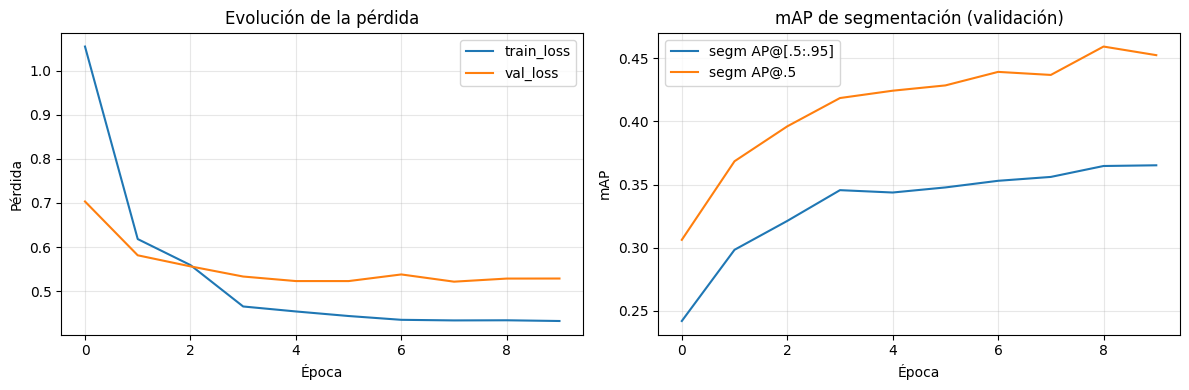

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="train_loss")
ax1.plot(history["val_loss"], label="val_loss")
ax1.set_xlabel("Época")
ax1.set_ylabel("Pérdida")
ax1.set_title("Evolución de la pérdida")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history["val_map"], label="segm AP@[.5:.95]")
ax2.plot(history["val_map50"], label="segm AP@.5")
ax2.set_xlabel("Época")
ax2.set_ylabel("mAP")
ax2.set_title("mAP de segmentación (validación)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Guardar el modelo



In [18]:
import os

best_ckpt = os.path.join(CHECKPOINT_DIR, "best.pth")
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pth")

print("¿Existe best.pth?", os.path.isfile(best_ckpt))
print("¿Existe last.pth?", os.path.isfile(last_ckpt))
print("Ruta:", CHECKPOINT_DIR)

¿Existe best.pth? True
¿Existe last.pth? True
Ruta: /content/drive/MyDrive/fashionpedia/checkpoints_768


## 10. Visualizar resultados de segmentación



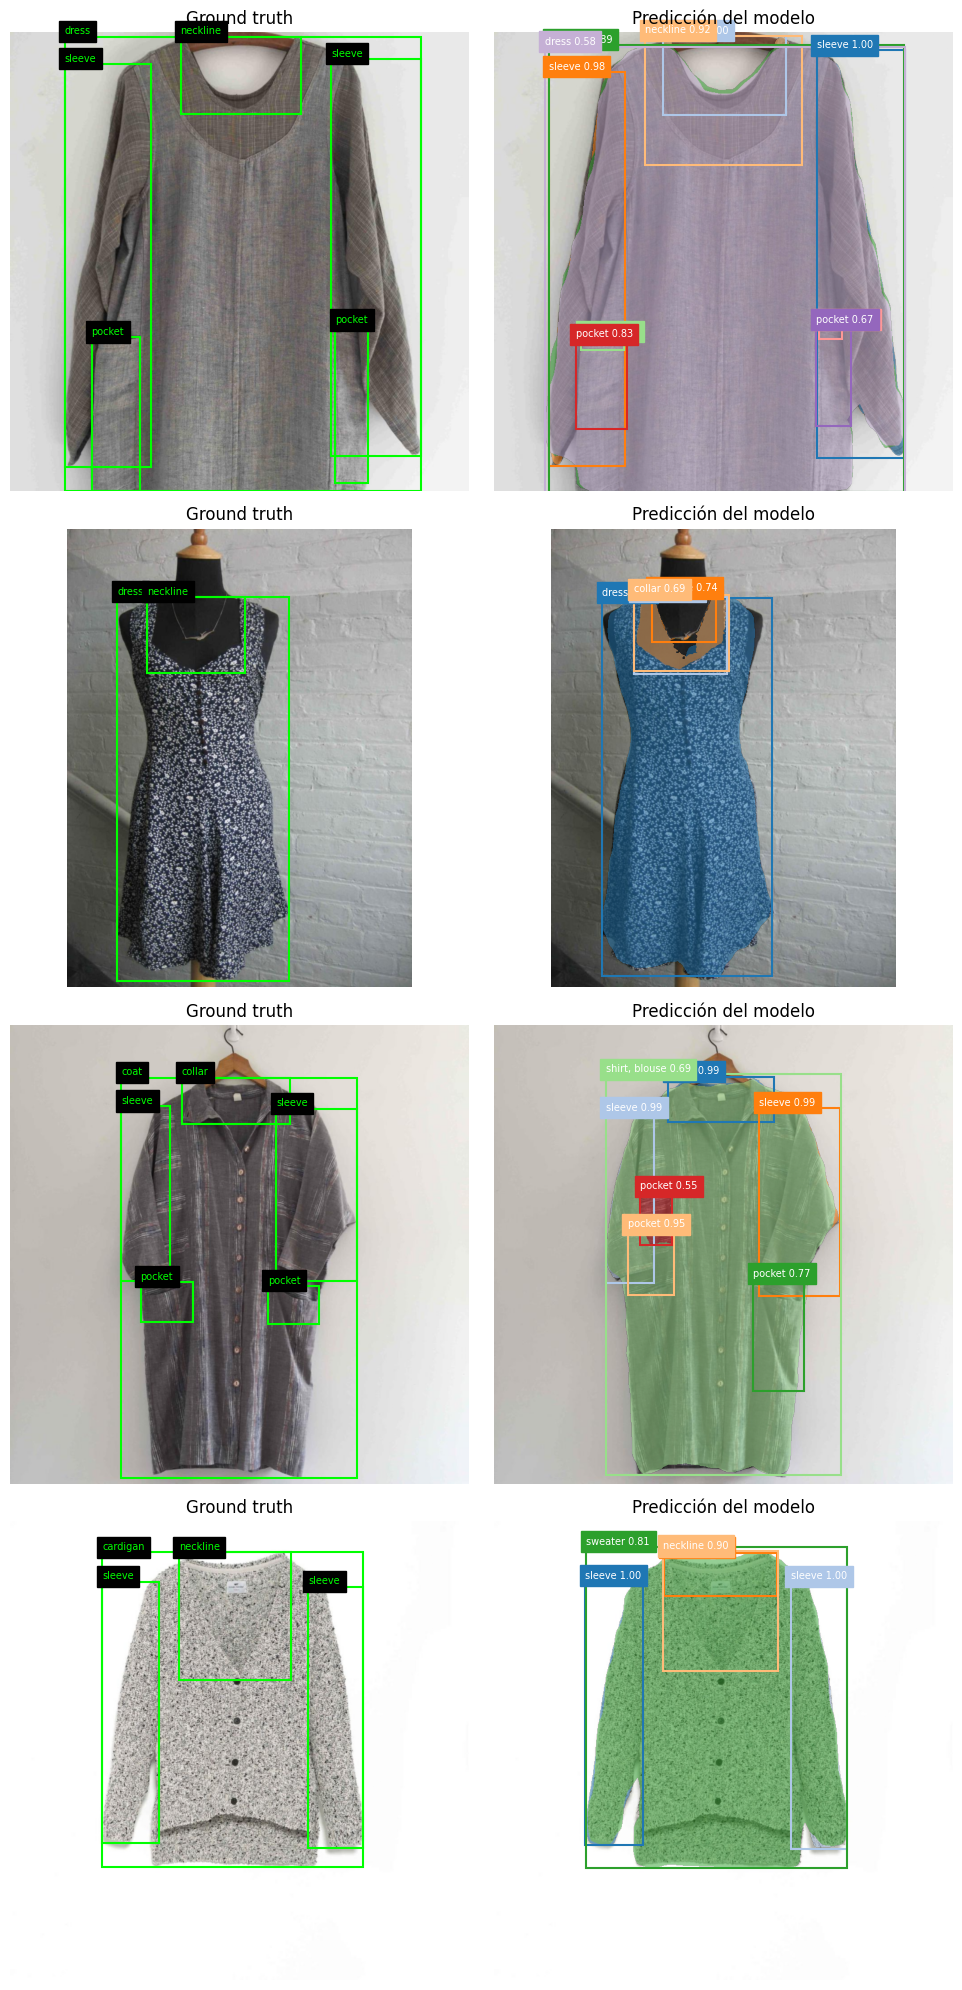

In [19]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

SCORE_THRESHOLD = 0.5

# Recarga el mejor modelo entrenado
inference_model = load_model(best_ckpt, num_classes=NUM_CLASSES, device=device)
inference_model.to(device)
inference_model.eval()

# Nombres de categorías (id COCO -> nombre) para las etiquetas del gráfico
catid_to_name = {c["id"]: c["name"] for c in test_dataset.coco.loadCats(test_dataset.coco.getCatIds())}


def plot_prediction(image_tensor, target, prediction, ax_gt, ax_pred, score_threshold=0.5):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    # --- Ground truth ---
    ax_gt.imshow(image_np)
    ax_gt.set_title("Ground truth")
    ax_gt.axis("off")
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="lime", facecolor="none")
        ax_gt.add_patch(rect)
        category_id = test_dataset.index_to_categoryid.get(int(label), None)
        name = catid_to_name.get(category_id, str(int(label)))
        ax_gt.text(x1, max(y1 - 4, 0), name, color="lime", fontsize=7, backgroundcolor="black")

    # --- Predicción ---
    ax_pred.imshow(image_np)
    ax_pred.set_title("Predicción del modelo")
    ax_pred.axis("off")

    mask_overlay = np.zeros((*image_np.shape[:2], 4))
    colors = plt.get_cmap("tab20")  # plt.cm.get_cmap se eliminó en matplotlib 3.9

    keep = prediction["scores"] >= score_threshold
    boxes = prediction["boxes"][keep].cpu()
    labels = prediction["labels"][keep].cpu()
    scores = prediction["scores"][keep].cpu()
    masks = prediction["masks"][keep].cpu()

    for i, (box, label, score, mask) in enumerate(zip(boxes, labels, scores, masks)):
        color = colors(i % 20)
        m = (mask[0].numpy() > 0.5)
        for c in range(3):
            mask_overlay[..., c] = np.where(m, color[c], mask_overlay[..., c])
        mask_overlay[..., 3] = np.where(m, 0.5, mask_overlay[..., 3])

        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor=color, facecolor="none")
        ax_pred.add_patch(rect)
        category_id = test_dataset.index_to_categoryid.get(int(label), None)
        name = catid_to_name.get(category_id, str(int(label)))
        ax_pred.text(x1, max(y1 - 4, 0), f"{name} {score:.2f}", color="white", fontsize=7, backgroundcolor=color)

    ax_pred.imshow(mask_overlay)


N_EXAMPLES = 4
indices = random.sample(range(len(test_dataset)), k=min(N_EXAMPLES, len(test_dataset)))

fig, axes = plt.subplots(len(indices), 2, figsize=(10, 5 * len(indices)))
if len(indices) == 1:
    axes = axes.reshape(1, 2)

with torch.no_grad():
    for row, idx in enumerate(indices):
        image_tensor, target = test_dataset[idx]
        prediction = inference_model([image_tensor.to(device)])[0]
        plot_prediction(image_tensor, target, prediction, axes[row, 0], axes[row, 1], SCORE_THRESHOLD)

plt.tight_layout()
plt.show()

## 11. Refinado con SAM 2 y lógica *prenda + partes − cierres*

Las máscaras de Mask R-CNN salen de una rejilla de 28×28 por detección, así que los bordes son blandos. Para recolorear o cambiar la textura hace falta una máscara más precisa. El pipeline es:

1. **Mask R-CNN** detecta las instancias (prendas, partes y cierres) y da su clase. La detección se hace a la misma escala con la que se entrenó (lado largo ≤ `MAX_SIDE`); las máscaras y cajas se devuelven en la resolución **original** de la imagen.
2. **SAM 2** refina cada instancia usando como *prompt* la caja de Mask R-CNN y un punto en el interior de su máscara. SAM propone 3 candidatas y nos quedamos con la que más se parece a la máscara de Mask R-CNN. **Salvaguarda:** si ninguna candidata se parece lo suficiente (IoU < 0.6), se conserva la máscara de Mask R-CNN (evita que SAM "se escape" a toda la prenda cuando el objeto es diminuto).
3. **Prenda + partes:** cada parte (manga, cuello, solapa, bolsillo, capucha...) se asigna a la prenda que más la contiene y se **suma** a su máscara.
4. **− Cierres:** cremalleras, hebillas, remaches, cuentas, lentejuelas y apliques que caen dentro de la prenda se **restan** (con una pequeña dilatación para no dejar halos).
5. **Solapes:** si dos prendas se solapan (chaqueta sobre camiseta), la de mayor prioridad se queda con la zona común.
6. Se genera un **alfa suave** (0–1) por prenda, que es lo que se pasa a las funciones de recoloreado/textura.

In [20]:
# SAM 2 necesita torch >= 2.5.1 (Colab ya lo trae). Si pip llegara a reinstalar torch,
# reinicia el entorno de ejecución y vuelve a ejecutar desde la sección 2.
!pip install -q "git+https://github.com/facebookresearch/sam2.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.8 MB/s eta 0:00:00


In [21]:
import cv2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Para ir más rápido / con menos memoria: "facebook/sam2.1-hiera-base-plus"
SAM2_MODEL_ID = "facebook/sam2.1-hiera-large"
sam_predictor = SAM2ImagePredictor.from_pretrained(SAM2_MODEL_ID, device=device.type)
print("SAM 2 cargado:", SAM2_MODEL_ID)

sam2.1_hiera_large.pt: reconstructing file:   0%|          |  0.00B /  898MB            

sam2.1_hiera_large.pt: downloading bytes:           |  0.00B            

SAM 2 cargado: facebook/sam2.1-hiera-large


### 11.1 Qué categorías se suman y cuáles se restan

Edita estos conjuntos a tu gusto. La celda comprueba que los nombres existan en tu JSON (los nombres de Fashionpedia llevan comas, p. ej. `"shirt, blouse"`).

- **`PRENDAS`**: las prendas que se van a recolorear.
- **`PARTES`**: se **suman** a la prenda a la que pertenecen.
- **`CIERRES`**: se **restan** (no se quiere recolorear una cremallera metálica ni unas lentejuelas).
- Lo que no está en ningún conjunto (`neckline`, `bow`, `ribbon`, `flower`, `fringe`, `tassel` y los accesorios) ni se suma ni se resta. `neckline` se deja fuera a propósito: su anotación suele incluir la abertura del cuello (piel).

In [22]:
PRENDAS = {
    "shirt, blouse", "top, t-shirt, sweatshirt", "sweater", "cardigan", "jacket", "vest",
    "pants", "shorts", "skirt", "coat", "dress", "jumpsuit", "cape",
}
PARTES = {"hood", "collar", "lapel", "epaulette", "sleeve", "pocket", "ruffle"}
CIERRES = {"zipper", "buckle", "rivet", "bead", "sequin", "applique"}
RELEVANTES = PRENDAS | PARTES | CIERRES

# Prioridad cuando dos prendas se solapan: la de mayor número se queda con la zona común.
PRIORIDAD = {
    "coat": 6, "cape": 6,
    "jacket": 5, "cardigan": 5,
    "vest": 4,
    "sweater": 3, "shirt, blouse": 3, "top, t-shirt, sweatshirt": 3,
    "dress": 2, "jumpsuit": 2,
    "pants": 1, "shorts": 1, "skirt": 1,
}

catid_to_name = {c["id"]: c["name"] for c in test_dataset.coco.loadCats(test_dataset.coco.getCatIds())}
LABEL2NAME = {idx: catid_to_name[cid] for idx, cid in test_dataset.index_to_categoryid.items()}

nombres_dataset = set(LABEL2NAME.values())
no_encontrados = RELEVANTES - nombres_dataset
if no_encontrados:
    print("⚠️ Estos nombres no existen en tu JSON, corrígelos arriba:", sorted(no_encontrados))
else:
    print("✓ Todos los nombres coinciden con las categorías del dataset")
print("Categorías que ni se suman ni se restan:", sorted(nombres_dataset - RELEVANTES))

✓ Todos los nombres coinciden con las categorías del dataset
Categorías que ni se suman ni se restan: ['bag, wallet', 'belt', 'bow', 'flower', 'fringe', 'glasses', 'glove', 'hat', 'headband, head covering, hair accessory', 'leg warmer', 'neckline', 'ribbon', 'scarf', 'shoe', 'sock', 'tassel', 'tie', 'tights, stockings', 'umbrella', 'watch']


### 11.2 Funciones del pipeline

In [23]:
# ---------- 1) Detección con Mask R-CNN (devuelve todo en la resolución ORIGINAL) ----------
@torch.no_grad()
def detectar(model, img_rgb, device, score_min=0.3):
    model.eval()
    H, W = img_rgb.shape[:2]

    # Misma escala con la que se entrenó: lado largo <= MAX_SIDE, sin deformar
    s = min(1.0, MAX_SIDE / max(H, W))
    small_w, small_h = max(1, round(W * s)), max(1, round(H * s))
    small = img_rgb if s == 1.0 else np.array(
        Image.fromarray(img_rgb).resize((small_w, small_h), Image.Resampling.BILINEAR))
    sx, sy = small_w / W, small_h / H

    tensor = torch.from_numpy(small).permute(2, 0, 1).float().div(255).to(device)
    out = model([tensor])[0]
    keep = out["scores"] >= score_min

    boxes = out["boxes"][keep].cpu().numpy().astype(np.float32)
    boxes[:, [0, 2]] = (boxes[:, [0, 2]] / sx).clip(0, W)
    boxes[:, [1, 3]] = (boxes[:, [1, 3]] / sy).clip(0, H)
    labels = out["labels"][keep].cpu().numpy()
    scores = out["scores"][keep].cpu().numpy()

    # Se reescalan las probabilidades (no la máscara binaria) y luego se umbraliza: bordes más suaves
    probs = out["masks"][keep, 0].cpu().numpy()
    masks = [cv2.resize(p, (W, H), interpolation=cv2.INTER_LINEAR) > 0.5 for p in probs]
    return boxes, labels, scores, masks


# ---------- 2) Refinado con SAM 2 ----------
def iou_mascaras(a, b):
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / union) if union else 0.0


def punto_interior(mask):
    """Punto (x, y) más interior de la máscara (máximo de la transformada de distancia)."""
    dist = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)
    y, x = np.unravel_index(dist.argmax(), dist.shape)
    return np.array([[x, y]], dtype=np.float32)


def refinar_con_sam(predictor, mask, box, iou_min=0.6):
    """Refina `mask` con SAM 2 (prompt = caja + punto interior). Devuelve (máscara, usó_sam)."""
    if not mask.any():
        return mask, False
    masks, _, _ = predictor.predict(
        point_coords=punto_interior(mask),
        point_labels=np.array([1]),
        box=np.asarray(box, dtype=np.float32),
        multimask_output=True,
    )
    candidatas = masks.astype(bool)
    ious = [iou_mascaras(c, mask) for c in candidatas]
    mejor = int(np.argmax(ious))
    if ious[mejor] < iou_min:      # SAM se ha ido a otra cosa: nos quedamos con Mask R-CNN
        return mask, False
    return candidatas[mejor], True


# ---------- 3) Prenda + partes - cierres ----------
def contenido_en(a, b):
    """Fracción del área de `a` que cae dentro de `b`."""
    area = a.sum()
    return float(np.logical_and(a, b).sum() / area) if area else 0.0


def combinar_instancias(instancias, shape, umbral_parte=0.5, umbral_cierre=0.2,
                        dilatar_cierres=2, suavizado=1.5):
    """
    instancias: lista de dicts con nombre, score, box, mask_rcnn, mask (ya refinada).
    Devuelve una entrada por prenda con:
      mask_final : bool (H, W) = prenda + partes - cierres (sin solapes con prendas de mayor prioridad)
      alpha      : float32 (H, W) en [0, 1], máscara suave lista para recolorear / texturizar
    """
    H, W = shape
    prendas = [dict(i, partes=[], cierres=0) for i in instancias if i["nombre"] in PRENDAS]
    partes = [i for i in instancias if i["nombre"] in PARTES]
    cierres = [i for i in instancias if i["nombre"] in CIERRES]
    if not prendas:
        return []

    for g in prendas:
        g["mask_prenda"] = g["mask"].copy()

    # 1) Cada parte se suma a la prenda que más la contiene (a igualdad, la prenda más pequeña)
    for p in partes:
        cont = [contenido_en(p["mask"], g["mask"]) for g in prendas]
        j = max(range(len(prendas)), key=lambda k: (round(cont[k], 3), -int(prendas[k]["mask"].sum())))
        if cont[j] >= umbral_parte:
            prendas[j]["partes"].append(p["nombre"])
            prendas[j]["mask_prenda"] |= p["mask"]

    # 2) Se restan los cierres que caen dentro de la prenda (con una pequeña dilatación)
    r = max(1, round(dilatar_cierres * max(H, W) / 1024))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
    for g in prendas:
        quitar = np.zeros((H, W), bool)
        for c in cierres:
            if contenido_en(c["mask"], g["mask_prenda"]) >= umbral_cierre:
                quitar |= c["mask"]
                g["cierres"] += 1
        if dilatar_cierres and quitar.any():
            quitar = cv2.dilate(quitar.astype(np.uint8), kernel) > 0
        g["mask_final"] = g["mask_prenda"] & ~quitar

    # 3) Solapes entre prendas: gana la de mayor prioridad. Se ocupa el área COMPLETA de la prenda
    #    (antes de restar cierres) para que, p. ej., la cremallera de la chaqueta no "regale" esa zona a la camiseta.
    ocupado = np.zeros((H, W), bool)
    for g in sorted(prendas, key=lambda g: -PRIORIDAD.get(g["nombre"], 0)):
        g["mask_final"] = g["mask_final"] & ~ocupado
        ocupado |= g["mask_prenda"]

    # 4) Alfa suave (el desenfoque se escala con el tamaño de la imagen)
    sigma = max(1.0, suavizado * max(H, W) / 1024)
    for g in prendas:
        g["alpha"] = np.clip(cv2.GaussianBlur(g["mask_final"].astype(np.float32), (0, 0), sigma), 0, 1)

    return sorted(prendas, key=lambda g: -g["score"])


def segmentar_prendas(det_model, predictor, img_rgb, device, score_prenda=0.5, score_otras=0.3,
                      usar_sam=True, **kwargs):
    """Pipeline completo. img_rgb: np.uint8 (H, W, 3) a resolución original."""
    boxes, labels, scores, masks = detectar(det_model, img_rgb, device, score_min=min(score_prenda, score_otras))

    candidatas = []
    for b, l, s, m in zip(boxes, labels, scores, masks):
        nombre = LABEL2NAME[int(l)]
        if nombre not in RELEVANTES:
            continue
        if s < (score_prenda if nombre in PRENDAS else score_otras):
            continue
        candidatas.append((nombre, float(s), b, m))

    if usar_sam and candidatas:
        predictor.set_image(img_rgb)   # el embedding de la imagen se calcula una sola vez

    instancias = []
    for nombre, s, b, m in candidatas:
        m_ref, ok = refinar_con_sam(predictor, m, b) if usar_sam else (m, False)
        instancias.append(dict(nombre=nombre, score=s, box=b, mask_rcnn=m, mask=m_ref, sam=ok))

    return combinar_instancias(instancias, img_rgb.shape[:2], **kwargs)

### 11.3 Probar el pipeline

Se cargan imágenes de test **a resolución original** (no las versiones reducidas del dataset) y se compara la máscara de Mask R-CNN sin refinar con el resultado final. El campo `alpha` de cada prenda (`resultado[i]["alpha"]`) es la máscara suave que debes pasar a las funciones de recoloreado/textura.

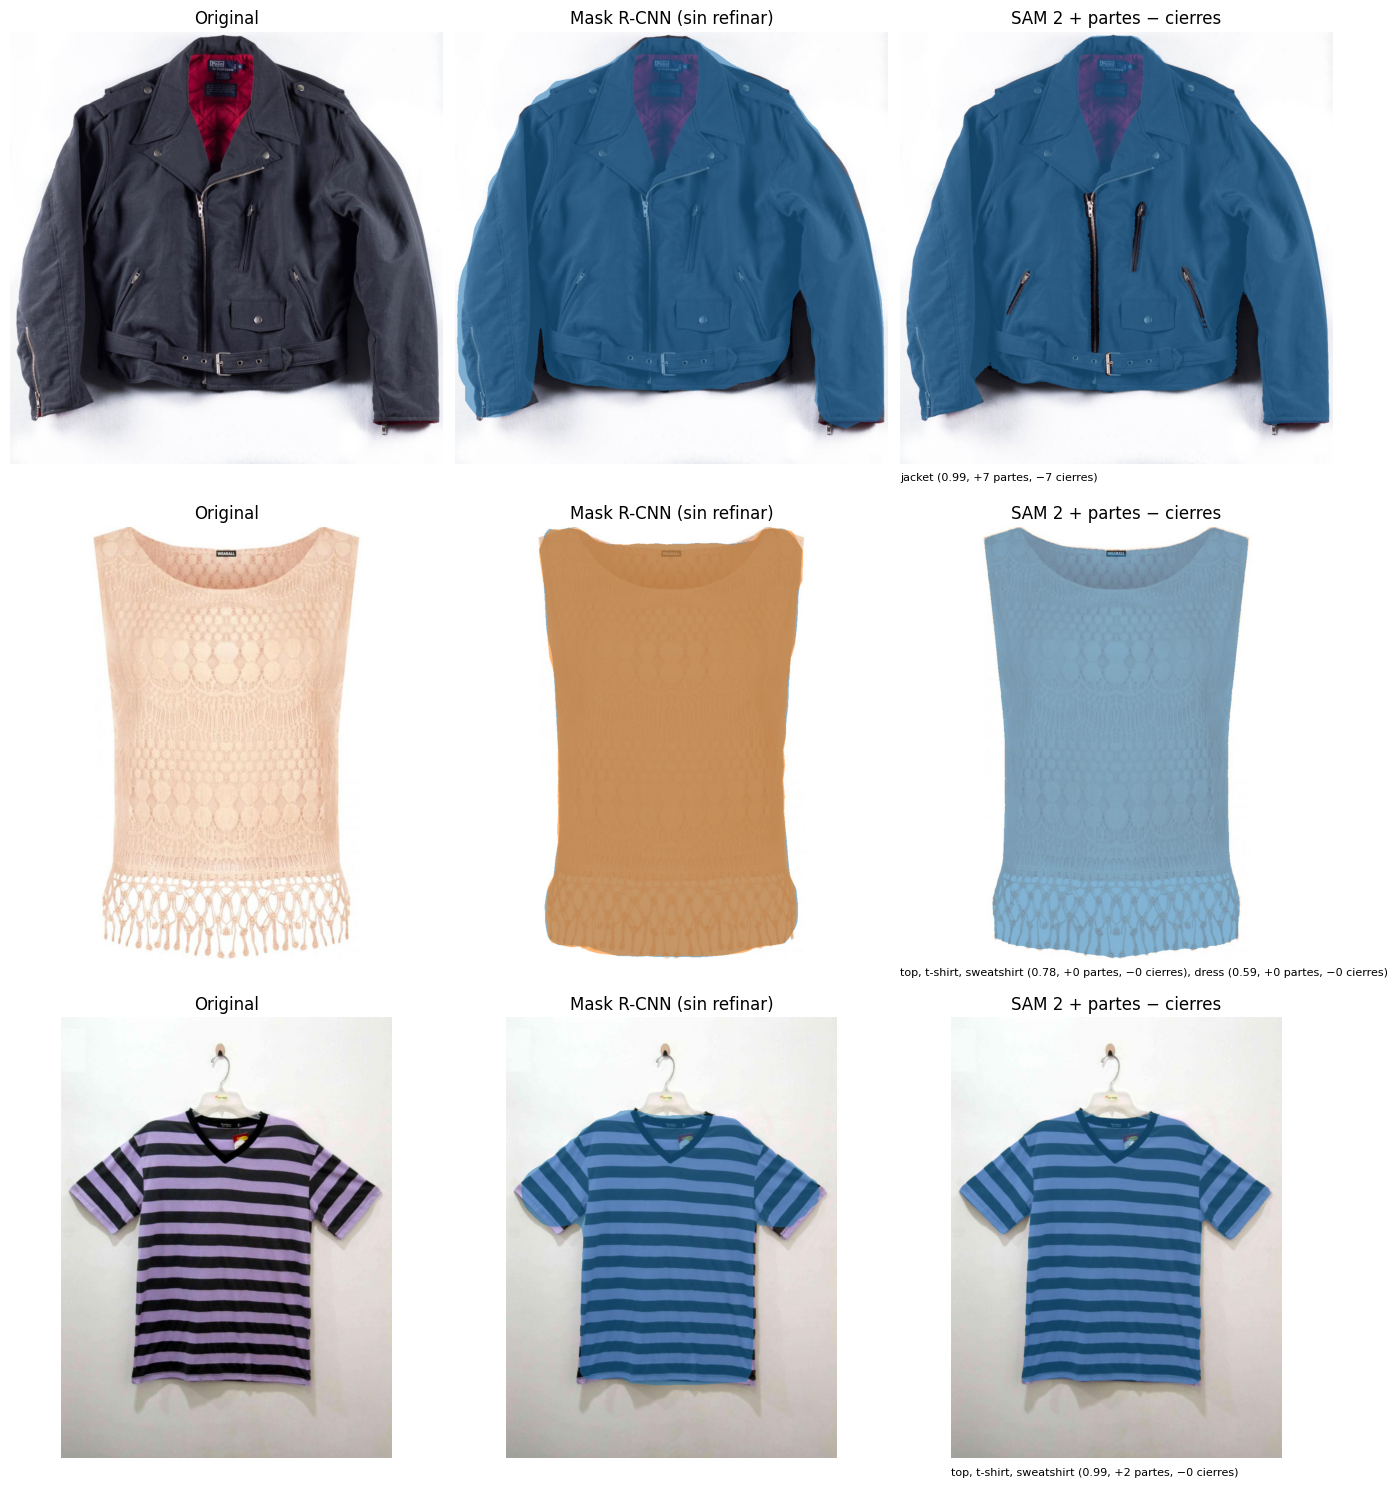

In [31]:
det_model = load_model(best_ckpt, num_classes=NUM_CLASSES, device=device)
det_model.to(device).eval()


def overlay(img, masks, alpha=0.55):
    out = img.astype(np.float32).copy()
    cmap = plt.get_cmap("tab10")
    for i, m in enumerate(masks):
        color = np.array(cmap(i % 10)[:3]) * 255
        out[m] = (1 - alpha) * out[m] + alpha * color
    return out.astype(np.uint8)


N_DEMO = 3
indices_demo = random.sample(range(len(test_dataset)), k=min(N_DEMO, len(test_dataset)))

fig, axes = plt.subplots(len(indices_demo), 3, figsize=(15, 5 * len(indices_demo)))
axes = np.atleast_2d(axes)

for row, idx in enumerate(indices_demo):
    info = test_dataset.coco.imgs[test_dataset.image_ids[idx]]
    img = np.array(Image.open(os.path.join(test_dataset.images_dir, info["file_name"])).convert("RGB"))

    prendas = segmentar_prendas(det_model, sam_predictor, img, device)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Original")
    axes[row, 1].imshow(overlay(img, [p["mask_rcnn"] for p in prendas]))
    axes[row, 1].set_title("Mask R-CNN (sin refinar)")
    axes[row, 2].imshow(overlay(img, [p["mask_final"] for p in prendas]))
    axes[row, 2].set_title("SAM 2 + partes − cierres")
    for ax in axes[row]:
        ax.axis("off")

    resumen = ", ".join(
        f'{p["nombre"]} ({p["score"]:.2f}, +{len(p["partes"])} partes, −{p["cierres"]} cierres)' for p in prendas
    ) or "ninguna prenda detectada"
    axes[row, 2].text(0, -0.02, resumen, transform=axes[row, 2].transAxes, va="top", fontsize=8)

plt.tight_layout()
plt.show()

---
### Notas
- Si Colab se desconecta o se agota la sesión, puedes reanudar el entrenamiento cargando `CHECKPOINT_DIR/last.pth` con `load_model(...)` y continuando desde ahí (basta con cargar el `state_dict` en un modelo nuevo antes de volver a llamar a `train_model`).
- Ajusta `BATCH_SIZE` según la memoria de la GPU asignada (una T4 de Colab suele aguantar `batch_size=2` con `image_size=256` sin problemas).
- `SCORE_THRESHOLD` controla qué tan seguras deben estar las predicciones para mostrarse; bájalo si no ves ninguna detección.
- Los checkpoints de esta versión están en `checkpoints_768/` y **no son compatibles con el flujo anterior** de 256 px (aunque los pesos se cargarían, el `last.pth` antiguo haría que el entrenamiento se diera por terminado). Para reanudar, no cambies `CHECKPOINT_DIR`.
- Si te quedas sin memoria en la GPU, baja `MAX_SIDE`/`MIN_SIZE` (p. ej. `MAX_SIDE=640`, `MIN_SIZE=(320, 352, 384, 416, 448)`) antes de tocar el batch.
- Si el mAP sube muy despacio, el `StepLR` (`LR_STEP_SIZE=3`) reduce el lr 10× cada 3 épocas; con 10 épocas prueba `LR_STEP_SIZE=4`.
- La salida de la sección 11 (`alpha` por prenda) es la entrada de las funciones de recoloreado y textura.

## Borrar carpetas de Google Drive

Para borrar carpetas de Google Drive, podemos usar la función `shutil.rmtree` de Python, que elimina un directorio y todo su contenido de forma recursiva. Es importante tener **mucho cuidado** al usar esta función, ya que los archivos eliminados no se pueden recuperar fácilmente.

Para usarla, primero debes especificar la ruta completa de las carpetas que deseas eliminar dentro de tu Google Drive. A continuación, te mostraré un ejemplo de cómo hacerlo. **Por favor, revisa las rutas cuidadosamente antes de ejecutar el código.**

In [ ]:
import shutil
import os

# Define las rutas de las carpetas que quieres eliminar
# ASEGÚRATE de que estas rutas son CORRECTAS y que quieres ELIMINAR su contenido.
# Por ejemplo:
# folder_to_delete_1 = '/content/drive/MyDrive/ruta/a/mi/carpeta_1'
# folder_to_delete_2 = '/content/drive/MyDrive/ruta/a/mi/carpeta_2'

# Ejemplo de rutas (AJUSTA ESTO A TUS CARPETAS REALES):
folder_to_delete_1 = '/content/drive/MyDrive/fashionpedia/not_human'
folder_to_delete_2 = '/content/drive/MyDrive/fashionpedia/not_human_test'

# Lista de carpetas a eliminar (puedes añadir más si es necesario)
folders_to_delete = [folder_to_delete_1, folder_to_delete_2]

for folder_path in folders_to_delete:
    if os.path.exists(folder_path):
        print(f"Eliminando carpeta: {folder_path}...")
        try:
            shutil.rmtree(folder_path)
            print(f"Carpeta {folder_path} eliminada con éxito.")
        except OSError as e:
            print(f"Error al eliminar la carpeta {folder_path}: {e}")
    else:
        print(f"La carpeta {folder_path} no existe. Saltando...")


Eliminando carpeta: /content/drive/MyDrive/fashionpedia/not_human...
Carpeta /content/drive/MyDrive/fashionpedia/not_human eliminada con éxito.
Eliminando carpeta: /content/drive/MyDrive/fashionpedia/not_human_test...
Carpeta /content/drive/MyDrive/fashionpedia/not_human_test eliminada con éxito.


Por favor, **ejecuta la celda anterior con mucha precaución** después de haber verificado que las rutas de las carpetas son las correctas y que realmente deseas eliminarlas. Una vez eliminadas, es muy difícil recuperar los datos.

¿Quieres que ajuste las rutas con los nombres de tus carpetas o tienes alguna otra pregunta?